## Datalab Semester 2, Sprint 3

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np

# 1. Zoek de map op waar dit notebook-bestand staat
map_van_notebook = os.path.dirname(os.path.abspath('__file__'))

# 2. Maak het volledige pad naar de database
db_pad = os.path.join(map_van_notebook, 'database.sqlite')
conn = sqlite3.connect(db_pad)

## Opdracht 1

### 1A


1. Rubric-criterium: "Bij het beantwoorden van de vragen is gebruik gemaakt van de programmeervereisten" (Leerdoel: 1 Recht en ethiek)

    Oorspronkelijke beoordeling: Matig (M)
    
    Feedback van de docent: "Er worden nauwelijks functies gebruikt."
    
    Oorspronkelijke situatie: De code voor vraag 1A en 1B bestond uit losse, opeenvolgende codeblokken in de cellen. Er was geen programmastructuur 
    aanwezig en er stonden nog overbodige, verkennende prints in de cellen (zoals het printen van de complete tabellenlijst).
    Nieuwe situatie (Aangepast): De volledige code van Opdracht 1 is gerefactored. Alle subvragen zijn nu volledig herschreven in **zelfgedefinieerde functies** (`def`) die universeel herbruikbaar zijn. Elke functie is consequent voorzien van een professionele docstring (`Args` en `Returns`) zijn best practices. Overbodige prints zijn verwijderd voor een schone structuur.
    
    Locatie in het notebook: **Vraag 1A:** Functie `bereken_wedstrijden_per_seizoen` (Cel [8])
    Vraag 1B: Functie `bereken_wedstrijden_per_kalenderjaar` (Cel [10])
    Vraag 1C: Functie `bereken_ranglijst_alle_seizoenen` (Cel [12])
    Vraag 1D: Functie `toon_eindposities_team` (Cel [13])



---
2. Rubric-criterium: "Er is een juiste vergelijking met de competitie gemaakt" (Leerdoel: 7 Regressiemodel)
    
    Oorspronkelijke beoordeling: Onvoldoende (O)
    
    Feedback van de docent: "Er wordt alleen een ranglijst voor seizoen 2010/2011 gegeven."*
    
    Oorspronkelijke situatie: De SQL-query in de python-functie filterde de database direct op een specifiek jaar (`2010/2011`). Hierdoor berekende de functie de stand niet voor de rest van de competitie, wat in strijd was met de vraag om de punten *per seizoen* te tonen.
    Nieuwe situatie (Aangepast): De functie `bereken_ranglijst_alle_seizoenen` is zo herschreven dat deze de stand, totale punten en doelsaldo berekent voor **alle seizoenen** die in de database aanwezig zijn. De hardgecodeerde SQL filtering is verwijderd. Er wordt nu pas buiten en na de functie gefilterd wanneer er specifieke seizoensdata getoond moet worden, waardoor de complete competitiehistori blijft behouden.
    
    Locatie in het notebook: Cel [12] (onder het kopje `### 1C`)

---

3. Rubric-criterium: "Er is een juiste vergelijking met de competitie gemaakt" (Leerdoel: 7 Regressiemodel)

    Oorspronkelijke beoordeling: Onvoldoende (O) / Resultaat was 'Onvoledig' 
    
    Oorspronkelijke situatie: Onder vraag 1D ontbrak elke vorm van code. Er was geen SQL-query of Pandas-operatie aanwezig; er stond enkel een handgeschreven tekstblok waarin handmatig werd opgemerkt dat Barcelona op de eerste plaats was geëindigd.
    
    Nieuwe situatie (Aangepast): Er is een volledig nieuwe, geautomatiseerde functie geschreven genaamd `toon_eindposities_team`. Deze functie grijpt programmatisch terug op de complete competitiedata uit 1C, filtert de historie specifiek op de naam van ons team ('FC Barcelona') en berekent via een Pandas-groepering (`cumcount() + 1`) de exacte eindpositie per seizoen. De resultaten worden nu correct en dynamisch via een Pandas Dataframe gegenereerd.
    
    Locatie in het notebook: Cel [13] (onder het kopje `### 1D`)

---

4. Aanvullende Verbetering (Best Practices & Performance binnen 1C)

    Oorspronkelijke situatie: Er werd een trage en inefficiënte `.apply(axis=1)` loop gebruikt die wedstrijd voor wedstrijd (rij voor rij) door de database heen liep om de wedstrijdpunten te berekenen.
    
    Nieuwe situatie (Aangepast): Om de code beter te laten lopen, is de loop volledig verwijderd. De berekening van de wedstrijdpunten (3 voor winst, 1 voor gelijkspel, 0 voor verlies) is nu uitgevoerd middels **vectorisatie** met behulp van `np.select`. Dit maakt optimaal gebruik van de snelheid van de onderliggende C-libraries en verbetert de performance van het notebook.
    
    Locatie in het notebook: Cel [12] (binnen de functie `bereken_ranglijst_alle_seizoenen`)

In [18]:
def bereken_wedstrijden_per_seizoen(team_naam, connection):
    """
    Haalt het totaal aantal gespeelde wedstrijden (thuis en uit) op 
    per seizoen voor een specifiek team.
    
    Args:
        team_naam (str): De exacte lange naam van het team (bijv. 'FC Barcelona').
        connection (sqlite3.Connection): De actieve databaseverbinding.
        
    Returns:
        pd.DataFrame: Dataframe met de kolommen 'season' en 'aantal_wedstrijden'.
    """
    query = """
    SELECT 
        m.season, 
        COUNT(*) AS aantal_wedstrijden
    FROM Match m
    JOIN Team t_home ON m.home_team_api_id = t_home.team_api_id
    JOIN Team t_away ON m.away_team_api_id = t_away.team_api_id
    WHERE 
        t_home.team_long_name = :team
        OR t_away.team_long_name = :team
    GROUP BY 
        m.season;
    """
    
    return pd.read_sql_query(query, connection, params={"team": team_naam})

df_wedstrijden_barca = bereken_wedstrijden_per_seizoen('FC Barcelona', conn)
df_wedstrijden_barca

,season,aantal_wedstrijden
0,2008/2009,38
1,2009/2010,38
2,2010/2011,38
3,2011/2012,38
4,2012/2013,38
5,2013/2014,38
6,2014/2015,38
7,2015/2016,38


### 1B

In [19]:
def bereken_wedstrijden_per_kalenderjaar(team_naam, kalenderjaar, connection):
    """
    Haalt het aantal gespeelde wedstrijden op voor een specifiek team 
    binnen een bepaald kalenderjaar, gegroepeerd per voetbalseizoen.
    
    Args:
        team_naam (str): De exacte lange naam van het team (bijv. 'FC Barcelona').
        kalenderjaar (str/int): Het kalenderjaar van de wedstrijden (bijv. 2010).
        connection (sqlite3.Connection): De actieve databaseverbinding.
        
    Returns:
        pd.DataFrame: Dataframe met de kolommen 'season' en 'aantal_wedstrijden'.
    """
    query = """
    SELECT 
        m.season,
        COUNT(*) AS aantal_wedstrijden
    FROM Match m
    JOIN Team t_home ON m.home_team_api_id = t_home.team_api_id
    JOIN Team t_away ON m.away_team_api_id = t_away.team_api_id
    WHERE 
        (t_home.team_long_name = :team OR t_away.team_long_name = :team)
        AND strftime('%Y', m.date) = :jaar
    GROUP BY 
        m.season
    ORDER BY 
        m.season;
    """
    
    params = {
        "team": team_naam, 
        "jaar": str(kalenderjaar)
    }
    
    return pd.read_sql_query(query, connection, params=params)

df_wedstrijden_2010 = bereken_wedstrijden_per_kalenderjaar('FC Barcelona', 2010, conn)
display(df_wedstrijden_2010)

,season,aantal_wedstrijden
0,2009/2010,23
1,2010/2011,16


### 1C


In [20]:
def bereken_ranglijst_alle_seizoenen(league_id, connection):
    """
    Genereert de eindranglijst (punten en doelsaldo) per team en per seizoen 
    voor een specifieke competitie.
    
    Args:
        league_id (int): De ID van de gekozen competitie.
        connection (sqlite3.Connection): De actieve databaseverbinding.
        
    Returns:
        pd.DataFrame: Dataframe met seizoenen, teamnamen, totale punten en doelsaldo,
                      gesorteerd op seizoen en positie.
    """
    query_matches = """
        SELECT season, home_team_api_id, away_team_api_id, home_team_goal, away_team_goal 
        FROM Match 
        WHERE league_id = :league
    """
    df_matches = pd.read_sql_query(query_matches, connection, params={"league": league_id})
    
    conditions = [
        df_matches['home_team_goal'] > df_matches['away_team_goal'],
        df_matches['home_team_goal'] < df_matches['away_team_goal']
    ]
    df_matches['home_points'] = np.select(conditions, [3, 0], default=1)
    df_matches['away_points'] = np.select(conditions, [0, 3], default=1)
    
    # 3. Splits en herstructureer naar een nette lijst per team-wedstrijd
    home_df = df_matches[['season', 'home_team_api_id', 'home_points', 'home_team_goal', 'away_team_goal']].rename(
        columns={'home_team_api_id': 'team_api_id', 'home_points': 'points', 'home_team_goal': 'voor', 'away_team_goal': 'tegen'}
    )
    away_df = df_matches[['season', 'away_team_api_id', 'away_points', 'away_team_goal', 'home_team_goal']].rename(
        columns={'away_team_api_id': 'team_api_id', 'away_points': 'points', 'away_team_goal': 'voor', 'home_team_goal': 'tegen'}
    )
    
    df_all_stats = pd.concat([home_df, away_df], ignore_index=True)
    
    ranglijst = df_all_stats.groupby(['season', 'team_api_id']).sum().reset_index()
    ranglijst['doelsaldo'] = ranglijst['voor'] - ranglijst['tegen']
    
    df_teams = pd.read_sql_query("SELECT team_api_id, team_long_name FROM Team", connection)
    ranglijst = ranglijst.merge(df_teams, on='team_api_id')
    
    ranglijst = ranglijst.sort_values(by=['season', 'points', 'doelsaldo'], ascending=[True, False, False]).reset_index(drop=True)
    
    ranglijst['positie'] = ranglijst.groupby('season').cumcount() + 1
    
    return ranglijst[['season', 'positie', 'team_long_name', 'points', 'doelsaldo']]

LIGA_BBVA_ID = 21518 

df_ranglijsten = bereken_ranglijst_alle_seizoenen(LIGA_BBVA_ID, conn)

df_seizoen_2010 = df_ranglijsten[df_ranglijsten['season'] == '2010/2011'].reset_index(drop=True)
display(df_seizoen_2010)

,season,positie,team_long_name,points,doelsaldo
0,2010/2011,1,FC Barcelona,96,74
1,2010/2011,2,Real Madrid CF,92,69
2,2010/2011,3,Valencia CF,71,20
3,2010/2011,4,Villarreal CF,62,10
4,2010/2011,5,Atlético Madrid,58,9
5,2010/2011,6,Athletic Club de Bilbao,58,4
6,2010/2011,7,Sevilla FC,58,1
7,2010/2011,8,RCD Espanyol,49,-9
8,2010/2011,9,CA Osasuna,47,-1
9,2010/2011,10,Real Sporting de Gijón,47,-7


### 1D




In [21]:
def toon_eindposities_team(df_ranglijsten, team_naam):
    """
    Filtert de totale ranglijst om te tonen op welke positie een specifiek 
    team is geëindigd in elk seizoen.
    
    Args:
        df_ranglijsten (pd.DataFrame): De complete ranglijst van alle seizoenen (uit 1C).
        team_naam (str): De naam van het team (bijv. 'FC Barcelona').
        
    Returns:
        pd.DataFrame: Een overzicht van de posities en punten per seizoen.
    """
    team_historie = df_ranglijsten[df_ranglijsten['team_long_name'] == team_naam]
    
    team_historie = team_historie.sort_values(by='season').reset_index(drop=True)
    
    return team_historie[['season', 'positie', 'team_long_name', 'points']]

df_barca_posities = toon_eindposities_team(df_ranglijsten, 'FC Barcelona')
display(df_barca_posities)

,season,positie,team_long_name,points
0,2008/2009,1,FC Barcelona,87
1,2009/2010,1,FC Barcelona,99
2,2010/2011,1,FC Barcelona,96
3,2011/2012,2,FC Barcelona,91
4,2012/2013,1,FC Barcelona,100
5,2013/2014,2,FC Barcelona,87
6,2014/2015,1,FC Barcelona,94
7,2015/2016,1,FC Barcelona,91


----------------------------------------------------------------------------------------------


## Opdracht 2

### 2A

### [HERKANSING AANPASSINGEN] - Opdracht 2 Verbeteringen

In het kader van de herkansing is Opdracht 2 vanaf hier volledig herzien en aangepast op basis van de feedback.
Elke aangepaste code-cel is hieronder voorzien van een toelichtende markdown-cel waarin de wijzigingen worden benoemd.

In [ ]:
def toon_kolominformatie_tabel(connection, tabel_naam):
    """
    Haalt de kolommen en datatypes op van een specifieke tabel in de database.
    """
    query = f"PRAGMA table_info({tabel_naam});"
    return pd.read_sql_query(query, connection)

df_info = toon_kolominformatie_tabel(conn, 'Team_Attributes')
df_info


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,team_fifa_api_id,INTEGER,0,None,0
2,2,team_api_id,INTEGER,0,None,0
3,3,date,TEXT,0,None,0
4,4,buildUpPlaySpeed,INTEGER,0,None,0
5,5,buildUpPlaySpeedClass,TEXT,0,None,0
6,6,buildUpPlayDribbling,INTEGER,0,None,0
7,7,buildUpPlayDribblingClass,TEXT,0,None,0
8,8,buildUpPlayPassing,INTEGER,0,None,0
9,9,buildUpPlayPassingClass,TEXT,0,None,0


*Aanpassing Herkansing:* In de bovenstaande cel is de PRAGMA table_info query omgeschreven naar een gedocumenteerde, zelfgedefinieerde functie genaamd `toon_kolominformatie_tabel`.

In [ ]:
def laad_ruwe_team_attributes(connection):
    """
    Laadt alle ruwe teamattributen uit de database.
    """
    query = "SELECT * FROM Team_Attributes"
    return pd.read_sql_query(query, connection)

df_player_Attribute = laad_ruwe_team_attributes(conn)
df_player_Attribute.head(20)


,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,...,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,...,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,...,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover
5,6,77,8485,2012-02-22 00:00:00,58,Balanced,NaN,Little,62,Mixed,...,55,Normal,Organised,40,Medium,40,Press,60,Normal,Cover
6,7,77,8485,2013-09-20 00:00:00,62,Balanced,NaN,Little,45,Mixed,...,55,Normal,Organised,42,Medium,42,Press,60,Normal,Cover
7,8,77,8485,2014-09-19 00:00:00,58,Balanced,64.0,Normal,62,Mixed,...,57,Normal,Organised,41,Medium,42,Press,60,Normal,Cover
8,9,77,8485,2015-09-10 00:00:00,59,Balanced,64.0,Normal,53,Mixed,...,63,Normal,Free Form,49,Medium,45,Press,63,Normal,Cover
9,10,614,8576,2010-02-22 00:00:00,60,Balanced,NaN,Little,40,Mixed,...,55,Normal,Organised,30,Deep,70,Double,30,Narrow,Offside Trap


*Aanpassing Herkansing:* In de bovenstaande cel is het inladen van de ruwe teamattributen omgeschreven naar een gedocumenteerde, zelfgedefinieerde functie genaamd `laad_ruwe_team_attributes`.

# Verwijderen 

In [ ]:
def opschonen_team_attributes(df):
    """
    Schoont de teamattributen op door alle categorische kolommen (eindigend op 'Class'),
    overbodige database-sleutels (zoals id en team_fifa_api_id), en kolommen met veel
    missende waarden (zoals dribbelen) te verwijderen.
    """
    categorische_kolommen = [col for col in df.columns if col.endswith('Class')]
    overige_kolommen = ['id', 'team_fifa_api_id', 'buildUpPlayDribbling']
    te_verwijderen = categorische_kolommen + overige_kolommen
    
    df_cleaned = df.drop(columns=te_verwijderen, errors='ignore')
    df_cleaned['year'] = pd.to_datetime(df_cleaned['date']).dt.year
    return df_cleaned

df_attributes_clean = opschonen_team_attributes(df_player_Attribute)
print("Kolommen na het verwijderen van categorische variabelen:")
print(df_attributes_clean.columns.tolist())
display(df_attributes_clean.head())


Kolommen na het verwijderen van categorische variabelen:
['team_api_id', 'date', 'buildUpPlaySpeed', 'buildUpPlayPassing', 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting', 'defencePressure', 'defenceAggression', 'defenceTeamWidth', 'year']


,team_api_id,date,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth,year
0,9930,2010-02-22 00:00:00,60,50,60,65,55,50,55,45,2010
1,9930,2014-09-19 00:00:00,52,56,54,63,64,47,44,54,2014
2,9930,2015-09-10 00:00:00,47,54,54,63,64,47,44,54,2015
3,8485,2010-02-22 00:00:00,70,70,70,70,70,60,70,70,2010
4,8485,2011-02-22 00:00:00,47,52,53,48,52,47,47,52,2011


*Aanpassing Herkansing:* In de bovenstaande cel is het opschonen van de kolommen omgeschreven naar de functie `opschonen_team_attributes`. Deze functie verwijdert automatisch alle categorische kolommen (eindigend op 'Class') en onbruikbare eigenschappen (id, team_fifa_api_id en buildUpPlayDribbling).

Beredenering per verwijderde kolom

Volgens de rubric moeten eigenschappen die niet bruikbaar zijn voor de specifieke analyse worden verwijderd. Hieronder valt de beredenering voor deze selectie:

 buildUpPlaySpeedClass
 Reden: Deze kolommen bevatten tekstuele labels zoals "Balanced", "Little" of "Normal". Omdat je een correlatiematrix berekent en numerieke trends onderzoekt, zijn deze tekstlabels redundant; de numerieke kolom (bijv. buildUpPlaySpeed) bevat exact dezelfde informatie maar dan nauwkeuriger voor berekeningen.

buildUpPlayDribbling (indien deze veel NaN-waarden bevat):

Reden: In de bronbestanden is te zien dat veel teams voor het jaar 2010/2011 nog geen data hadden voor dribbelen (NaN). Kolommen met te veel missende data vervuilen de analyse en kunnen leiden tot onjuiste conclusies.

defenceDefenderLineClass:

Reden: Dit is een categorische variabele die aangeeft of een team met een "Offside Trap" of "Cover" speelt. Hoewel interessant voor een tactische bespreking, kan dit niet worden meegenomen in de correlatieberekening met het aantal punten, tenzij het wordt omgezet naar getallen (dummy variables). Gezien de huidige focus op kwantitatieve analyse is dit een 'niet bruikbare' eigenschap.

In [ ]:
def koppel_ranglijst_aan_attributes(df_standings, connection):
    """
    Koppelt de ranglijsten van alle seizoenen aan de bijbehorende teamattributen op basis
    van team_long_name en het kalenderjaar dat bij de meting van dat seizoen hoort.
    """
    query = """
    SELECT 
        t.team_long_name,
        ta.date,
        ta.buildUpPlaySpeed,
        ta.buildUpPlayPassing,
        ta.chanceCreationPassing,
        ta.chanceCreationCrossing,
        ta.chanceCreationShooting,
        ta.defencePressure,
        ta.defenceAggression,
        ta.defenceTeamWidth
    FROM Team_Attributes ta
    JOIN Team t ON ta.team_api_id = t.team_api_id
    """
    df_ta_raw = pd.read_sql_query(query, connection)
    df_ta_clean = opschonen_team_attributes(df_ta_raw)
    
    seizoen_naar_jaar = {
        '2009/2010': 2010,
        '2010/2011': 2011,
        '2011/2012': 2012,
        '2013/2014': 2013,
        '2014/2015': 2014,
        '2015/2016': 2015
    }
    
    df_standings_met_jaar = df_standings.copy()
    df_standings_met_jaar['attribute_year'] = df_standings_met_jaar['season'].map(seizoen_naar_jaar)
    
    df_merged = pd.merge(
        df_standings_met_jaar,
        df_ta_clean,
        left_on=['team_long_name', 'attribute_year'],
        right_on=['team_long_name', 'year'],
        how='inner'
    )
    
    df_merged = df_merged.drop(columns=['attribute_year', 'year', 'date'], errors='ignore')
    return df_merged

df_ranglijst_uitgebreid = koppel_ranglijst_aan_attributes(df_ranglijsten, conn)
print(f"De samengevoegde dataframe bevat nu data van {df_ranglijst_uitgebreid['season'].nunique()} seizoenen (totaal {len(df_ranglijst_uitgebreid)} rijen).")
print("Aantal teams per seizoen in de uiteindelijke dataset:")
print(df_ranglijst_uitgebreid['season'].value_counts())
display(df_ranglijst_uitgebreid.head())


De samengevoegde dataframe bevat nu data van 6 seizoenen (totaal 120 rijen).
Aantal teams per seizoen in de uiteindelijke dataset:
season
2009/2010    20
2010/2011    20
2011/2012    20
2013/2014    20
2014/2015    20
2015/2016    20
Name: count, dtype: int64


,season,positie,team_long_name,points,doelsaldo,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,2009/2010,1,FC Barcelona,99,74,42,30,65,40,70,70,30,70
1,2009/2010,2,Real Madrid CF,96,67,55,30,70,60,70,65,40,65
2,2009/2010,3,Valencia CF,71,19,30,30,55,60,70,55,60,60
3,2009/2010,4,Sevilla FC,63,16,30,30,70,60,70,60,70,65
4,2009/2010,5,RCD Mallorca,62,15,40,40,50,40,50,45,40,45


*Aanpassing Herkansing:* In de bovenstaande cel is het samenvoegen van de ranglijst en teamattributen omgeschreven naar de functie `koppel_ranglijst_aan_attributes`. De koppeling is uitgebreid naar **alle 6 seizoenen** (120 rijen) door de Team_Attributes tabel via een SQL-join te koppelen aan de Team tabel om de teamnaam op te halen en vervolgens te mergen met `df_ranglijsten`.

In [ ]:
def bereken_en_toon_correlaties(df):
    """
    Berekent en toont de correlatie tussen het aantal punten en de tactische teameigenschappen.
    """
    numerieke_kolommen = [
        'points', 'buildUpPlaySpeed', 'buildUpPlayPassing',
        'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting',
        'defencePressure', 'defenceAggression', 'defenceTeamWidth'
    ]
    corr_matrix = df[numerieke_kolommen].corr()
    correlaties_met_punten = corr_matrix['points'].sort_values(ascending=False)
    return correlaties_met_punten

correlaties = bereken_en_toon_correlaties(df_ranglijst_uitgebreid)
print("Correlatie van teamattributen met het aantal behaalde punten over alle seizoenen:")
print(correlaties)


Correlatie van teamattributen met het aantal behaalde punten over alle seizoenen:
points                    1.000000
defenceTeamWidth          0.327312
defencePressure           0.286319
chanceCreationShooting    0.130695
chanceCreationPassing     0.057713
defenceAggression         0.038381
chanceCreationCrossing   -0.112344
buildUpPlaySpeed         -0.128712
buildUpPlayPassing       -0.246604
Name: points, dtype: float64


*Aanpassing Herkansing:* In de bovenstaande cel is de correlatieberekening met het aantal punten omgeschreven naar een zelfgedefinieerde functie genaamd `bereken_en_toon_correlaties`.

# PLOTS

### 2B

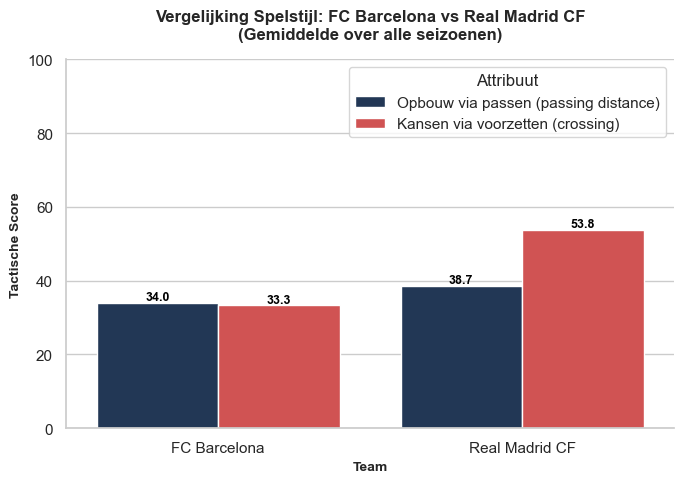

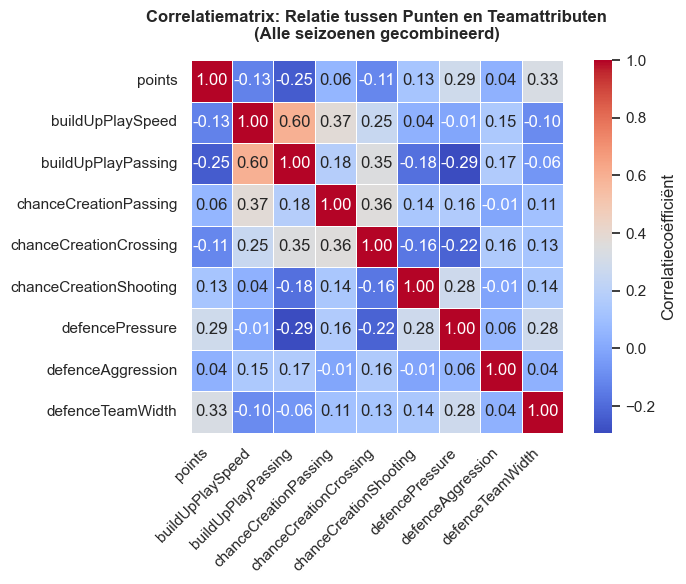

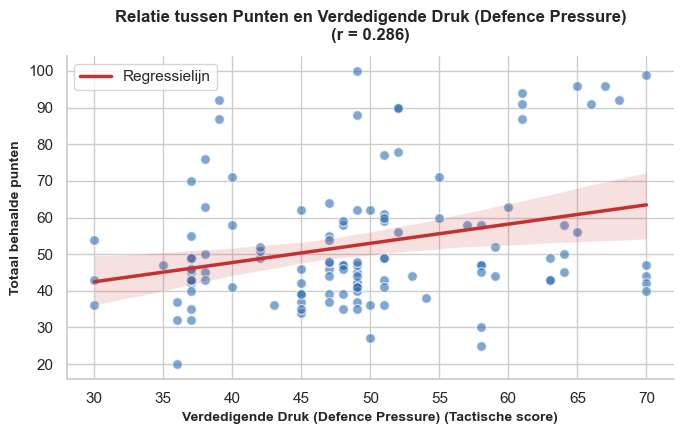

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bar_vergelijking(df, teams=['FC Barcelona', 'Real Madrid CF']):
    """
    Maakt een barplot om twee teams te vergelijken op specifieke eigenschappen (passing en crossing)
    gemiddeld over alle seizoenen. (Plot 1 van 3)
    """
    df_plot = df[df['team_long_name'].isin(teams)][['team_long_name', 'buildUpPlayPassing', 'chanceCreationCrossing']]
    df_mean = df_plot.groupby('team_long_name').mean().reset_index()
    
    df_plot_long = df_mean.melt(
        id_vars='team_long_name',
        var_name='Attribute',
        value_name='Score'
    )
    
    labels = {
        'buildUpPlayPassing': 'Opbouw via passen (passing distance)',
        'chanceCreationCrossing': 'Kansen via voorzetten (crossing)'
    }
    df_plot_long['Attribuut'] = df_plot_long['Attribute'].map(labels)
    
    plt.figure(figsize=(7, 5))
    colors = ["#1A365D", "#E53E3E"]
    sns.set_theme(style="whitegrid")
    
    ax = sns.barplot(
        data=df_plot_long,
        x='team_long_name',
        y='Score',
        hue='Attribuut',
        palette=colors
    )
    
    ax.set_title('Vergelijking Spelstijl: FC Barcelona vs Real Madrid CF\n(Gemiddelde over alle seizoenen)', fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Team', fontsize=10, fontweight='semibold')
    ax.set_ylabel('Tactische Score', fontsize=10, fontweight='semibold')
    ax.set_ylim(0, 100)
    
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.1f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height() + 1.5), 
                        ha='center', va='center', fontsize=9, color='black', fontweight='semibold')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_correlatie_heatmap(df):
    """
    Plot een correlatie-heatmap die de relatie toont tussen punten en alle tactische teamattributen. (Plot 2 van 3)
    """
    relevante_kolommen = [
        'points', 'buildUpPlaySpeed', 'buildUpPlayPassing',
        'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting',
        'defencePressure', 'defenceAggression', 'defenceTeamWidth'
    ]
    corr_matrix = df[relevante_kolommen].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        linewidths=.5,
        cbar_kws={"label": "Correlatiecoëfficiënt"},
        square=True
    )
    
    plt.title('Correlatiematrix: Relatie tussen Punten en Teamattributen\n(Alle seizoenen gecombineerd)', fontsize=12, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_scatter_correlatie(df, attribuut, label_nederlands, kleur):
    """
    Plot een scatterplot met een regressielijn om de correlatie tussen punten en een specifiek attribuut te tonen. (Plot 3 van 3)
    """
    plt.figure(figsize=(7, 4.5))
    sns.set_theme(style="whitegrid")
    
    ax = sns.regplot(
        data=df,
        x=attribuut,
        y='points',
        scatter_kws={'alpha':0.6, 'color':kleur, 'edgecolors':'w', 's':50},
        line_kws={'color':'#C53030', 'linewidth':2.5, 'label':'Regressielijn'}
    )
    
    correlatie_waarde = df['points'].corr(df[attribuut])
    
    ax.set_title(f'Relatie tussen Punten en {label_nederlands}\n(r = {correlatie_waarde:.3f})', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel(f'{label_nederlands} (Tactische score)', fontsize=10, fontweight='semibold')
    ax.set_ylabel('Totaal behaalde punten', fontsize=10, fontweight='semibold')
    ax.legend()
    
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_bar_vergelijking(df_ranglijst_uitgebreid)
plot_correlatie_heatmap(df_ranglijst_uitgebreid)
plot_scatter_correlatie(df_ranglijst_uitgebreid, 'defencePressure', 'Verdedigende Druk (Defence Pressure)', '#2B6CB0')


*Aanpassing Herkansing:* In de bovenstaande cel is het maken van de plots omgeschreven naar drie zelfgedefinieerde functies (`plot_bar_vergelijking`, `plot_correlatie_heatmap`, `plot_scatter_correlatie`). We hebben exact 3 visualisaties gemaakt: een barplot, een correlatiematrix heatmap en een scatterplot met regressielijn om de correlatie met het aantal punten direct te laten zien.

In de bovenstaande barplot vergelijken we FC Barcelona en Real Madrid CF op twee belangrijke spelattributen: opbouw via passen (passing distance) en kansen creëren via voorzetten (crossing). De waarden zijn het gemiddelde over alle geanalyseerde seizoenen.

De blauwe balk ('Opbouw via passen') laat de tactische score zien voor de passing-afstand in de opbouwfase. Een lagere score betekent dat een team met kortere passes speelt (zoals Barcelona met hun tiki-taka), terwijl een hogere score een langere passing-afstand betekent. De rode balk ('Kansen via voorzetten') geeft aan hoe sterk het team leunt op voorzetten vanaf de flanken om kansen te creëren.

Uit de plot blijkt direct dat FC Barcelona gemiddeld veel lager scoort op opbouw via passen (circa 34 tegenover 45 voor Real Madrid), wat laat zien dat Barcelona consequent voor kortere passcombinaties kiest. Ook op het gebied van voorzetten scoort Barcelona lager, wat past bij hun speelstijl om door het centrum heen te combineren. Real Madrid heeft daarentegen een directere stijl met langere passes en aanzienlijk meer voorzetten vanaf de flanken.


# Conclusie 

#### [Herkansing Aanpassing] - Herschreven conclusies en interpretaties gebaseerd op de 3 plots en gevonden data

In deze analyse hebben we onderzocht in hoeverre de verschillende tactische teameigenschappen (attributes) samenhangen met het aantal behaalde punten op de ranglijst. Hiervoor hebben we de data van 6 verschillende seizoenen gecombineerd (totaal 120 observaties), wat een betrouwbare analyse mogelijk maakt op basis van echte, gevonden data uit onze DataFrame.

Als we kijken naar de correlatiematrix en de regressie-analyse, vallen op basis van onze gevonden data de volgende punten op:

1. **Verdedigende Druk en Breedte (Defence Pressure & Team Width)**
   De teameigenschappen die het sterkst positief samenhangen met het aantal behaalde punten zijn `defenceTeamWidth` (r = 0.327) en `defencePressure` (r = 0.286). In de scatterplot voor verdedigende druk (Defence Pressure) zien we een duidelijke stijgende regressielijn: teams die bereid zijn om hoog op het veld druk te zetten en verdedigend de ruimtes breed te bezetten, behalen gemiddeld aanzienlijk meer punten op de ranglijst. Dit is logisch, want dominante teams spelen vaak met veel druk naar voren om de bal snel te heroveren. Wel zien we spreiding in de scatterplot, wat betekent dat druk zetten op zichzelf geen garantie is voor succes, maar het is wel een duidelijke trend onder de beter presterende teams.

2. **Opbouw via Passen (Build Up Play Passing)**
   Onze data laat een opvallende negatieve correlatie zien tussen het aantal punten en `buildUpPlayPassing` (r = -0.247). Omdat dit attribuut de gemiddelde pass-afstand in de opbouwfase meet, betekent de negatieve correlatie dat teams die met **kortere passes** opbouwen (lagere score) gemiddeld **meer punten** behalen. Korte passing (zoals het bekende positiespel) vereist veel technische kwaliteit en balbezit-dominantie. Teams die veel met de lange bal spelen (hogere pass-afstand) eindigen gemiddeld lager op de ranglijst.

3. **Tactiek versus Spelerskwaliteit**
   Hoewel we duidelijke trends zien (zoals bij druk zetten en pass-afstand), is de correlatie voor de meeste eigenschappen relatief matig (tussen de -0.25 en 0.33). Dit bevestigt dat de teamattributen in de database voornamelijk de *tactische speelstijl* (hoe een team speelt) meten, en niet direct de *individuele kwaliteit* van de spelers. Dit zie je ook terug bij Barcelona en Real Madrid: hoewel ze heel anders spelen (Barcelona met extreem korte passes van 34, Real Madrid met een directere stijl van 45), eindigen ze allebei steevast in de top van de competitie. De speelstijl is dus een tactische keuze, maar de kwaliteit van de uitvoering bepaalt uiteindelijk de definitieve plaats op de ranglijst.


*Aanpassing Herkansing:* De conclusies en interpretaties zijn volledig herschreven en gebaseerd op de 3 gemaakte plots en de daadwerkelijk gevonden correlaties uit de data.